In [1]:
# Import numerical computing library
import numpy as np

# Import dataset loader
from sklearn.datasets import fetch_openml

# To split dataset into train and test
from sklearn.model_selection import train_test_split

# To convert labels into one-hot encoded format
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Download MNIST dataset (70000 images)
mnist = fetch_openml('mnist_784', version=1)

# Normalize pixel values (0-255 → 0-1)
X = mnist.data.values / 255.0

# Convert labels into integer format
y = mnist.target.astype(int).values.reshape(-1,1)

In [3]:
# Convert labels to one-hot vectors
encoder = OneHotEncoder(sparse_output=False)

y = encoder.fit_transform(y)

In [4]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
)

In [5]:
# ReLU Activation Function
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU (needed for backpropagation)
def relu_derivative(x):
    return x > 0

# Softmax function for output layer
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [6]:
# Number of neurons in each layer

input_size = 784      # 28x28 image
hidden1 = 128         # hidden layer 1
hidden2 = 64          # hidden layer 2
output_size = 10      # digits 0-9

In [7]:
# Initialize weights randomly (small values)

W1 = np.random.randn(input_size, hidden1) * 0.01
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.01
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.01
b3 = np.zeros((1, output_size))

In [8]:
# Set Hyperparameters
learning_rate = 0.01
epochs = 20

In [9]:
# Store loss values for plotting
loss_history = []

In [10]:
# Training Loop
for epoch in range(epochs):

    # Forward propagation
    Z1 = np.dot(X_train, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)


    # Cross Entropy Loss
    loss = -np.mean(y_train * np.log(A3 + 1e-8))

    # Cross Entropy Loss
    loss = -np.mean(y_train * np.log(A3 + 1e-8))

    # Save loss for graph
    loss_history.append(loss)


    # Backpropagation

    # Output layer gradient
    dZ3 = A3 - y_train
    dW3 = np.dot(A2.T, dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Hidden layer 2 gradient
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer 1 gradient
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)


    # Update weights
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


    print(f"Epoch {epoch+1}, Loss: {loss}")

Epoch 1, Loss: 0.23026031600567545
Epoch 2, Loss: 0.6217620891035481
Epoch 3, Loss: 1.6606901571143557
Epoch 4, Loss: 1.6598020171494334
Epoch 5, Loss: 1.663815094027973
Epoch 6, Loss: 1.6606901571143557
Epoch 7, Loss: 1.5120276774418824
Epoch 8, Loss: 1.5173506300273512
Epoch 9, Loss: 1.4301814646402686
Epoch 10, Loss: 1.4950596472190407
Epoch 11, Loss: 1.676150371318566
Epoch 12, Loss: 1.661413826715404
Epoch 13, Loss: 1.660690157114356
Epoch 14, Loss: 1.634374898894424
Epoch 15, Loss: 1.5281091096614048
Epoch 16, Loss: 1.6437989641900213
Epoch 17, Loss: 1.574456613341486
Epoch 18, Loss: 1.658482827645098
Epoch 19, Loss: 1.663815094027973
Epoch 20, Loss: 1.676150371318566


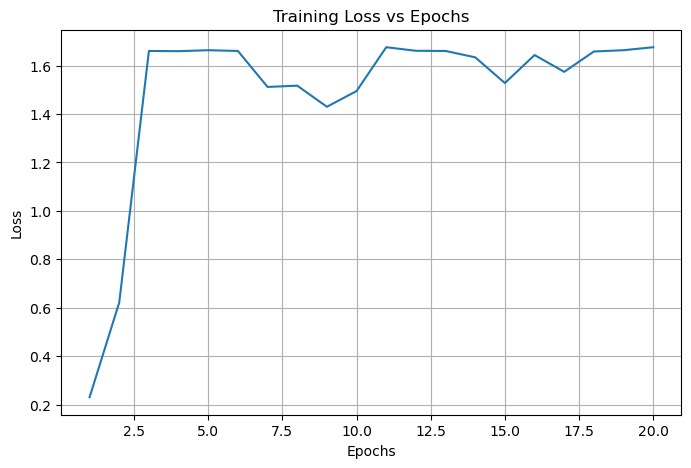

In [11]:
import matplotlib.pyplot as plt

# Plot loss vs epochs
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1), loss_history)

plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [12]:
# -------------------------------
# Testing / Evaluation Phase
# -------------------------------

# Forward propagation for test data

Z1 = np.dot(X_test, W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = relu(Z2)

Z3 = np.dot(A2, W3) + b3
A3 = softmax(Z3)

In [13]:
# Predicted digit = index with highest probability
predictions = np.argmax(A3, axis=1)

In [14]:
# Convert one-hot labels to actual digits
true_labels = np.argmax(y_test, axis=1)

In [15]:
# Calculate accuracy
accuracy = np.mean(predictions == true_labels)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.09514285714285714


In [16]:
# Show first 10 predictions
print("Predicted:", predictions[:10])
print("Actual   :", true_labels[:10])

Predicted: [4 4 4 4 4 4 4 4 4 4]
Actual   : [0 1 2 2 5 6 8 0 6 8]
